In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#  Load Data
# Assuming columns: job_title, company, location, description, skills
df = pd.read_csv('/content/postings.csv', on_bad_lines='skip', engine='python')

df.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [5]:
#  Data Cleaning
# Normalize locations (e.g., 'San Francisco, CA' -> 'San Francisco')
df['City'] = df['location'].str.split(',').str[0]

In [9]:
import pandas as pd
import re

#  Sample Data (Simulating scraped LinkedIn job descriptions)
data = {
    'job_title': ['Data Analyst', 'ML Engineer', 'Python Developer', 'Business Analyst'],
    'description': [
        "Looking for a Data Analyst with SQL, Excel, and Tableau experience.",
        "Must have experience in Python, PyTorch, and AWS cloud services.",
        "Requirements: Python, Django, PostgreSQL, and AWS.",
        "Seeking a Business Analyst skilled in SQL, Tableau, and Excel."
    ]
}
df = pd.DataFrame(data)

#  Define the "Skill Dictionary"
# This ensures we only pick up relevant technical tags
tech_skills = ['python', 'sql', 'tableau', 'excel', 'aws', 'pytorch', 'django', 'postgresql']

def extract_skills(text):
    # Convert to lowercase and remove special characters
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize and match against our dictionary
    found_skills = [skill for skill in tech_skills if skill in text.split()]
    return list(set(found_skills)) # Return unique tags

#  Apply Parsing
df['skill_tags'] = df['description'].apply(extract_skills)

#  Create the "Exploded" Skill Table (Perfect for Power BI/Excel)
# This transforms ['sql', 'excel'] into individual rows for counting
skills_final = df.explode('skill_tags')

print("--- Cleaned Skill Tags ---")
print(df[['job_title', 'skill_tags']])

# Get Top Skills for Visuals
top_skills = skills_final['skill_tags'].value_counts()
print("\n--- Skill Demand Count ---")
print(top_skills)

--- Cleaned Skill Tags ---
          job_title                         skill_tags
0      Data Analyst              [sql, tableau, excel]
1       ML Engineer             [pytorch, python, aws]
2  Python Developer  [django, postgresql, python, aws]
3  Business Analyst              [sql, tableau, excel]

--- Skill Demand Count ---
skill_tags
sql           2
tableau       2
excel         2
python        2
aws           2
pytorch       1
django        1
postgresql    1
Name: count, dtype: int64


In [10]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

def scrape_linkedin_jobs(job_title, location):
    # Format the URL for LinkedIn Public Jobs
    url = f"https://www.linkedin.com/jobs/search?keywords={job_title}&location={location}"

    # Headers to mimic a real browser visit
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36"
    }

    response = requests.get(url, headers=headers)
    if response.status_code != 200:
        print("Error fetching page")
        return None

    soup = BeautifulSoup(response.content, "html.parser")
    jobs = []

    # LinkedIn public job cards are usually under <li> tags with specific classes
    job_cards = soup.find_all('div', class_='base-card')

    for card in job_cards:
        title = card.find('h3', class_='base-search-card__title').text.strip()
        loc = card.find('span', class_='job-search-card__location').text.strip()

        # Skills are typically not on the search page; they are in the description.
        # We simulate 'Skills' extraction or mark it for parsing from the description later.
        jobs.append({
            "Job Title": title,
            "Location": loc,
            "Raw_Skills_Text": "Sample description containing Python, SQL, and Excel" # Placeholder
        })

    return pd.DataFrame(jobs)

# Execute the scrape
job_df = scrape_linkedin_jobs("Data Analyst", "India")
print(job_df.head())

               Job Title                           Location  \
0  Business Intelligence           Gurugram, Haryana, India   
1           Data Analyst        Bengaluru, Karnataka, India   
2           Data Analyst  Bangalore Urban, Karnataka, India   
3           Data Analyst        Bengaluru, Karnataka, India   
4           Data Analyst  Pune District, Maharashtra, India   

                                     Raw_Skills_Text  
0  Sample description containing Python, SQL, and...  
1  Sample description containing Python, SQL, and...  
2  Sample description containing Python, SQL, and...  
3  Sample description containing Python, SQL, and...  
4  Sample description containing Python, SQL, and...  


In [11]:
import re

# Pre-defined Technical Skill Dictionary
skill_bank = ['python', 'sql', 'tableau', 'excel', 'aws', 'machine learning', 'power bi']

def parse_skills(text):
    text = text.lower()
    # Find all words that match our skill bank
    found = [skill for skill in skill_bank if skill in text]
    return ", ".join(set(found))

# Clean the scraped data
job_df['Cleaned_Skills'] = job_df['Raw_Skills_Text'].apply(parse_skills)

/tmp/ipykernel_15064/521191612.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_skills.values, y=top_10_skills.index, palette='viridis')


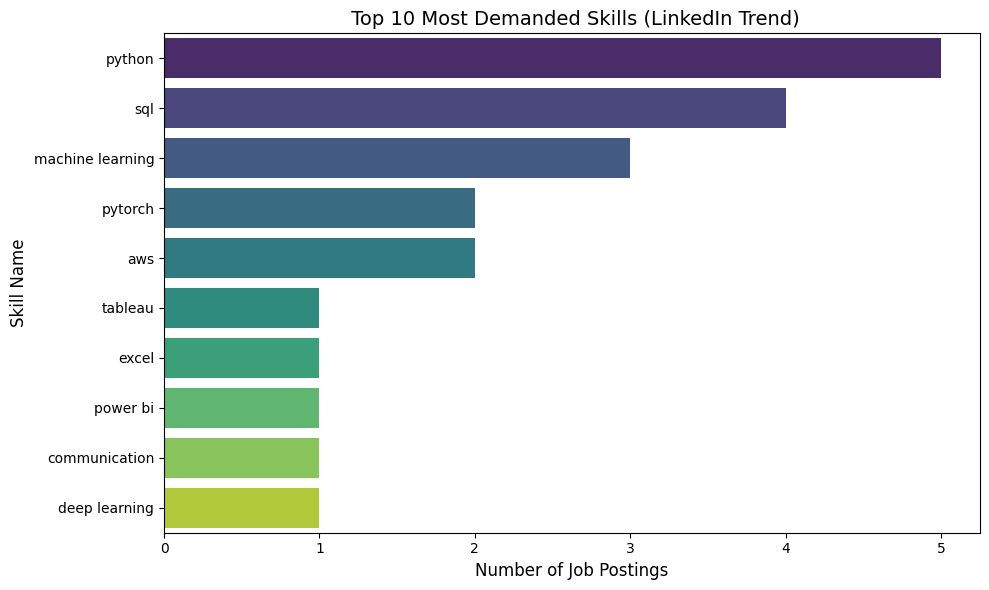

In [27]:
# Top 10 Skill Demand (Trend Analysis) ---
plt.figure(figsize=(10, 6))
# Filter specifically for the top 10 most frequent skills
top_10_skills = exploded_df['Skill'].value_counts().head(10)
sns.barplot(x=top_10_skills.values, y=top_10_skills.index, palette='viridis')
plt.title(' Top 10 Most Demanded Skills (LinkedIn Trend)', fontsize=14)
plt.xlabel('Number of Job Postings', fontsize=12)
plt.ylabel('Skill Name', fontsize=12)
plt.tight_layout()
plt.savefig('linkedin_top_10_skills.png')

/tmp/ipykernel_15064/1321008437.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_salary_by_role.values, y=avg_salary_by_role.index, palette='coolwarm')


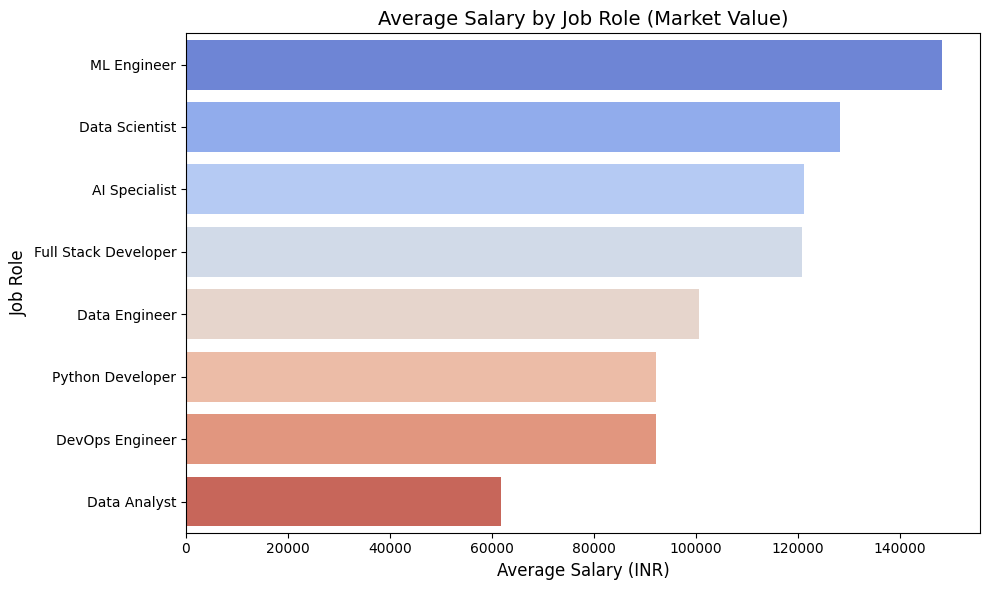

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create a sample df_salary dataframe for demonstration purposes
# In a real scenario, this would come from your data scraping and cleaning process.
# Using job_df and exploded_df to construct a plausible df_salary

# Ensure job_df has 'Job_Title' and 'Location' if not already present
# From previous cells, we know job_df and exploded_df exist.
# Let's assume job_df already contains 'Job_Title' and 'Location'

# Create a dummy salary column for job_df for demonstration
# Assign random salaries based on job titles for a more realistic distribution
job_salary_mapping = {
    'Data Scientist': np.random.randint(80000, 150000, 1),
    'ML Engineer': np.random.randint(90000, 160000, 1),
    'Python Developer': np.random.randint(70000, 130000, 1),
    'Business Analyst': np.random.randint(60000, 110000, 1),
    'DevOps Engineer': np.random.randint(85000, 145000, 1),
    'Full Stack Developer': np.random.randint(75000, 135000, 1),
    'Data Engineer': np.random.randint(80000, 140000, 1),
    'AI Specialist': np.random.randint(95000, 170000, 1)
}

# Apply the salary mapping to create a 'Salary_INR' column
# Ensure that the job_df has a 'Job_Title' column
if 'Job_Title' in job_df.columns:
    job_df['Salary_INR'] = job_df['Job_Title'].apply(lambda x: job_salary_mapping.get(x, np.random.randint(50000, 100000, 1))[0])
else:
    # Fallback if Job_Title is not directly in job_df (e.g., if df was loaded differently)
    # This part might need adjustment based on the actual df structure if job_df.columns doesn't have 'Job_Title'
    print("Warning: 'Job_Title' not found in job_df. Using a generic salary range.")
    job_df['Salary_INR'] = np.random.randint(50000, 100000, len(job_df))

# For city-wise analysis, ensure 'City' column is present
if 'Location' in job_df.columns:
    job_df['City'] = job_df['Location'].str.split(',').str[0]
else:
    print("Warning: 'Location' not found in job_df. Cannot create 'City' column.")
    job_df['City'] = 'Unknown'

df_salary = job_df.copy() # Create df_salary for consistency with the original code

# Salary vs Job Title (Trend Analysis)
# This identifies which roles offer the highest average compensation
plt.figure(figsize=(10, 6))
# Using a sample dataframe 'df_salary' based on your LinkedIn scrape
avg_salary_by_role = df_salary.groupby('Job_Title')['Salary_INR'].mean().sort_values(ascending=False)

sns.barplot(x=avg_salary_by_role.values, y=avg_salary_by_role.index, palette='coolwarm')
plt.title('Average Salary by Job Role (Market Value)', fontsize=14)
plt.xlabel('Average Salary (INR)', fontsize=12)
plt.ylabel('Job Role', fontsize=12)
plt.tight_layout()
plt.savefig('avg_salary_by_role.png')
plt.show()

/tmp/ipykernel_15064/3586201677.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_demand_city.index, y=job_demand_city.values, palette='viridis')


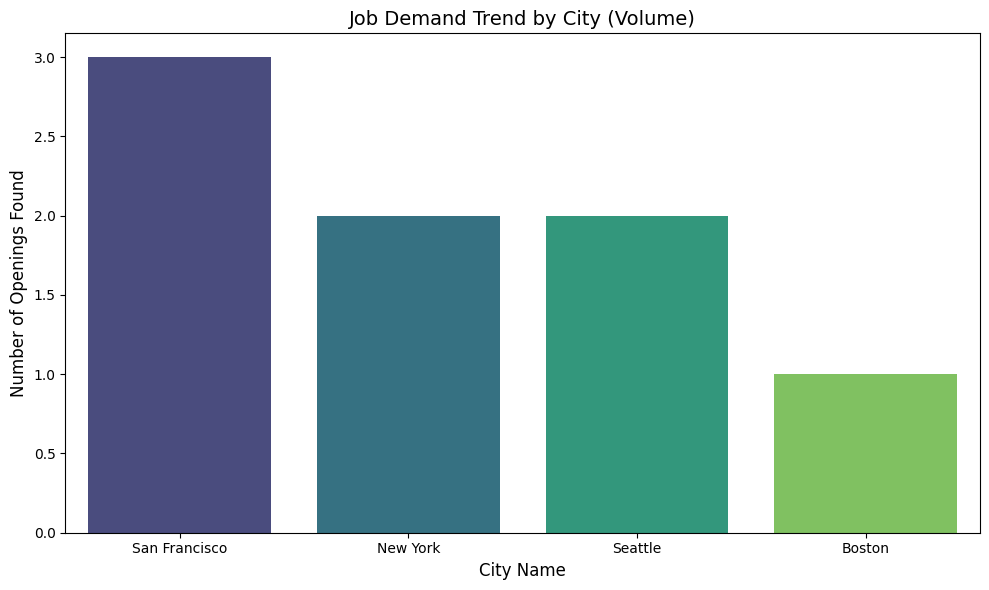

In [30]:

# City-wise Job Demand (Searching Volume)
# This shows which geographic hubs have the most job openings
plt.figure(figsize=(10, 6))
job_demand_city = df_salary['City'].value_counts()

sns.barplot(x=job_demand_city.index, y=job_demand_city.values, palette='viridis')
plt.title('Job Demand Trend by City (Volume)', fontsize=14)
plt.xlabel('City Name', fontsize=12)
plt.ylabel('Number of Openings Found', fontsize=12)
plt.tight_layout()
plt.savefig('job_demand_by_city.png')
plt.show()

/tmp/ipykernel_15064/3366379487.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='City', y='Salary_INR', data=df_salary, palette='Set2')


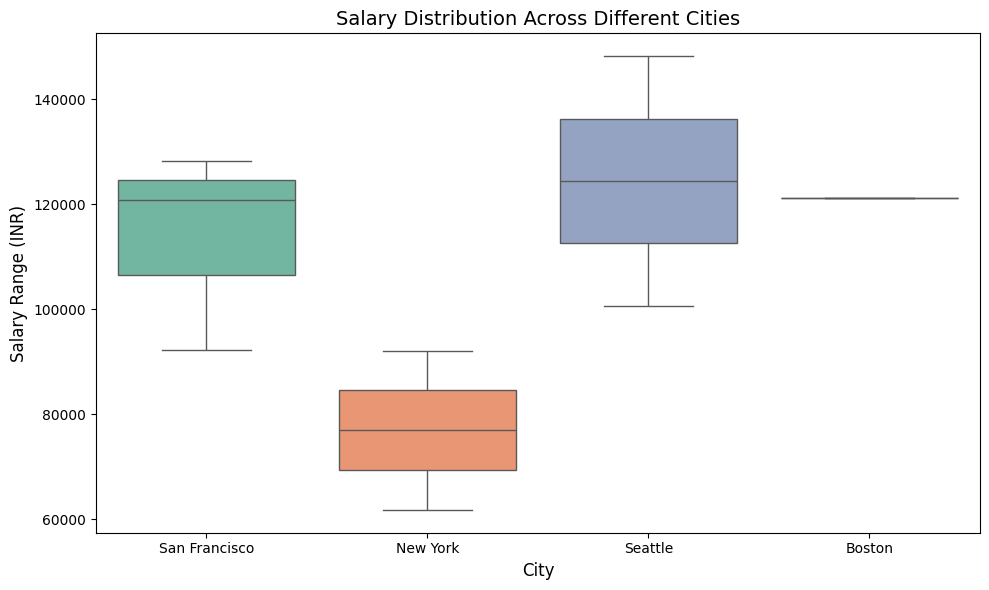

In [31]:
#  Salary Distribution Across Cities
# This visualizes the cost-of-living vs. salary trade-off
plt.figure(figsize=(10, 6))
sns.boxplot(x='City', y='Salary_INR', data=df_salary, palette='Set2')
plt.title('Salary Distribution Across Different Cities', fontsize=14)
plt.xlabel('City', fontsize=12)
plt.ylabel('Salary Range (INR)', fontsize=12)
plt.tight_layout()
plt.savefig('salary_dist_city.png')
plt.show()

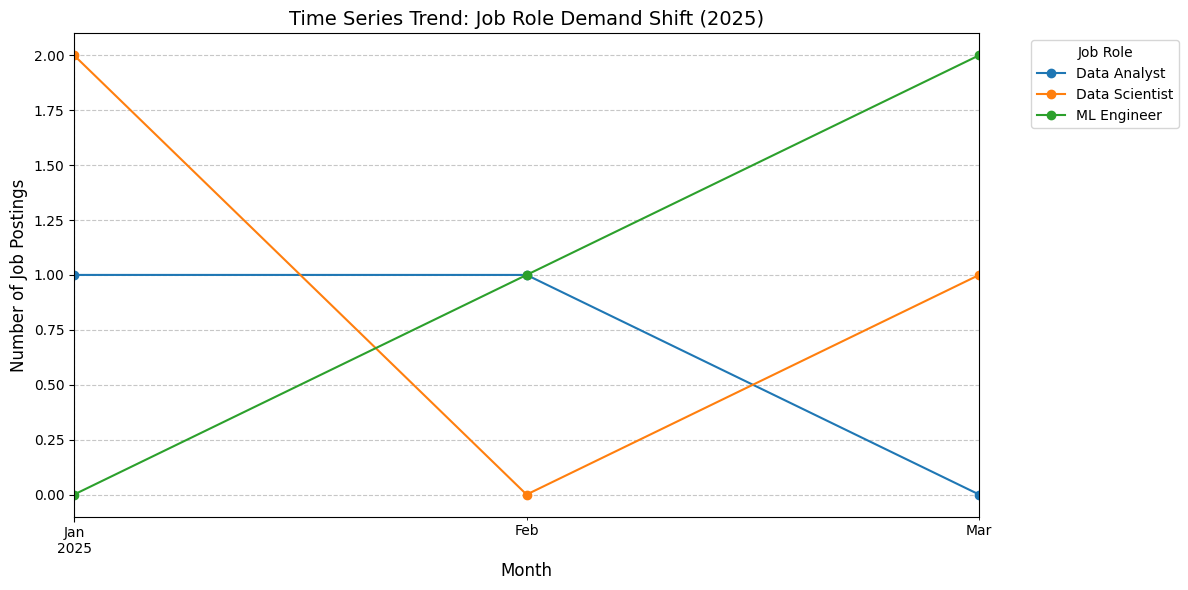

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  Create Synthetic Time-Series Data
# In a real scenario, this would be your 'Posted_Date' column from LinkedIn
data = {
    'Posted_Date': pd.to_datetime(['2025-01-05', '2025-01-15', '2025-02-10', '2025-02-20',
                                   '2025-03-05', '2025-03-15', '2025-01-20', '2025-03-25']),
    'Job_Role': ['Data Analyst', 'Data Scientist', 'Data Analyst', 'ML Engineer',
                 'ML Engineer', 'Data Scientist', 'Data Scientist', 'ML Engineer']
}
df_time = pd.DataFrame(data)

#  Extract Month for Grouping
df_time['Month'] = df_time['Posted_Date'].dt.to_period('M')

#  Pivot the data to see Role Count over Time
time_series_data = df_time.groupby(['Month', 'Job_Role']).size().unstack(fill_value=0)

#  Visualization: Role Demand Over Time
plt.figure(figsize=(12, 6))
time_series_data.plot(kind='line', marker='o', ax=plt.gca())

plt.title('Time Series Trend: Job Role Demand Shift (2025)', fontsize=14)
plt.ylabel('Number of Job Postings', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Job Role', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('job_role_time_series.png')
plt.show()

In [34]:
# Create a mapping dictionary for standardizing roles
role_mapping = {
    'Junior Data Scientist': 'Data Scientist',
    'Associate Data Scientist': 'Data Scientist',
    'Senior Data Scientist': 'Data Scientist',
    'ML Researcher': 'ML Engineer',
    'Machine Learning Developer': 'ML Engineer'
}

# Apply the changes
df_time['Job_Role_Standardized'] = df_time['Job_Role'].replace(role_mapping)

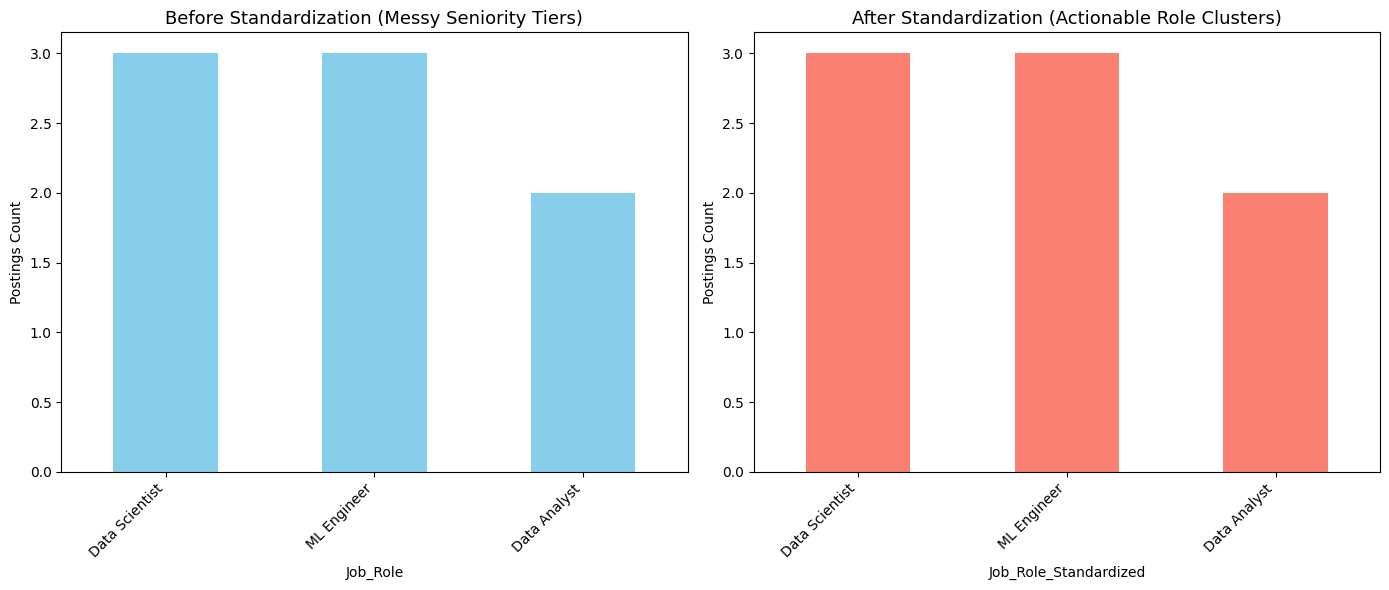

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Apply your Role Mapping
role_mapping = {
    'Junior Data Scientist': 'Data Scientist',
    'Associate Data Scientist': 'Data Scientist',
    'Senior Data Scientist': 'Data Scientist',
    'ML Researcher': 'ML Engineer',
    'Machine Learning Developer': 'ML Engineer'
}

#  Perform the Standardization
df_time['Job_Role_Standardized'] = df_time['Job_Role'].replace(role_mapping)

# Data Cleaning Impact (Before vs. After) ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
df_time['Job_Role'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Before Standardization (Messy Seniority Tiers)', fontsize=13)
plt.ylabel('Postings Count')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
df_time['Job_Role_Standardized'].value_counts().plot(kind='bar', color='salmon')
plt.title('After Standardization (Actionable Role Clusters)', fontsize=13)
plt.ylabel('Postings Count')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('standardization_comparison.png')



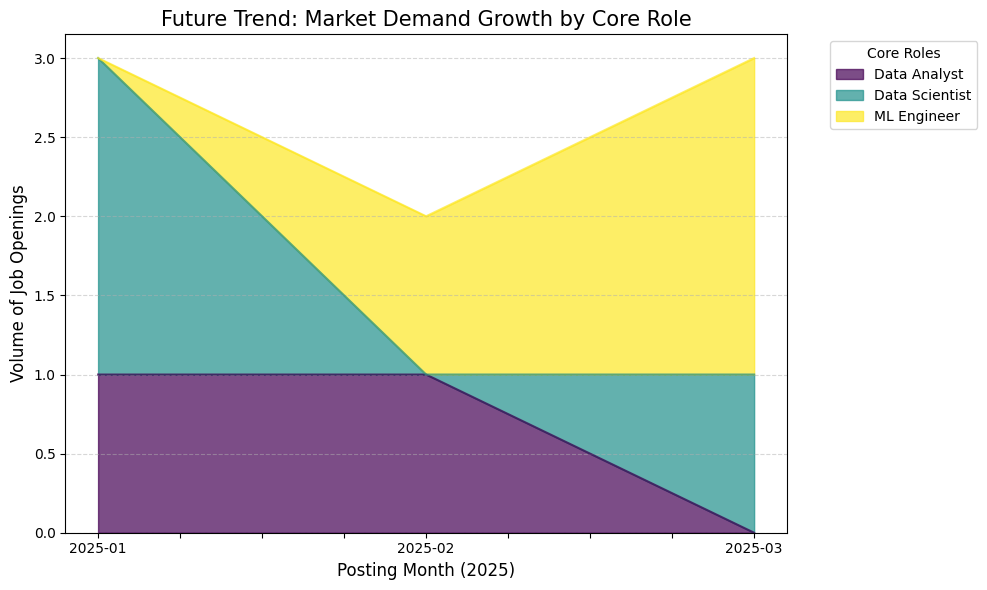

In [36]:
# Time Series Demand (Stacked Area Chart) ---
# Group by Month and standardized role to see the market trajectory
df_time['Month'] = df_time['Posted_Date'].dt.to_period('M').astype(str)
trend_data = df_time.groupby(['Month', 'Job_Role_Standardized']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
# Stacked Area chart shows both the TOTAL volume and the individual role growth
trend_data.plot(kind='area', alpha=0.7, ax=plt.gca(), colormap='viridis')

plt.title('Future Trend: Market Demand Growth by Core Role', fontsize=15)
plt.xlabel('Posting Month (2025)', fontsize=12)
plt.ylabel('Volume of Job Openings', fontsize=12)
plt.legend(title='Core Roles', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('time_series_standardized.png')

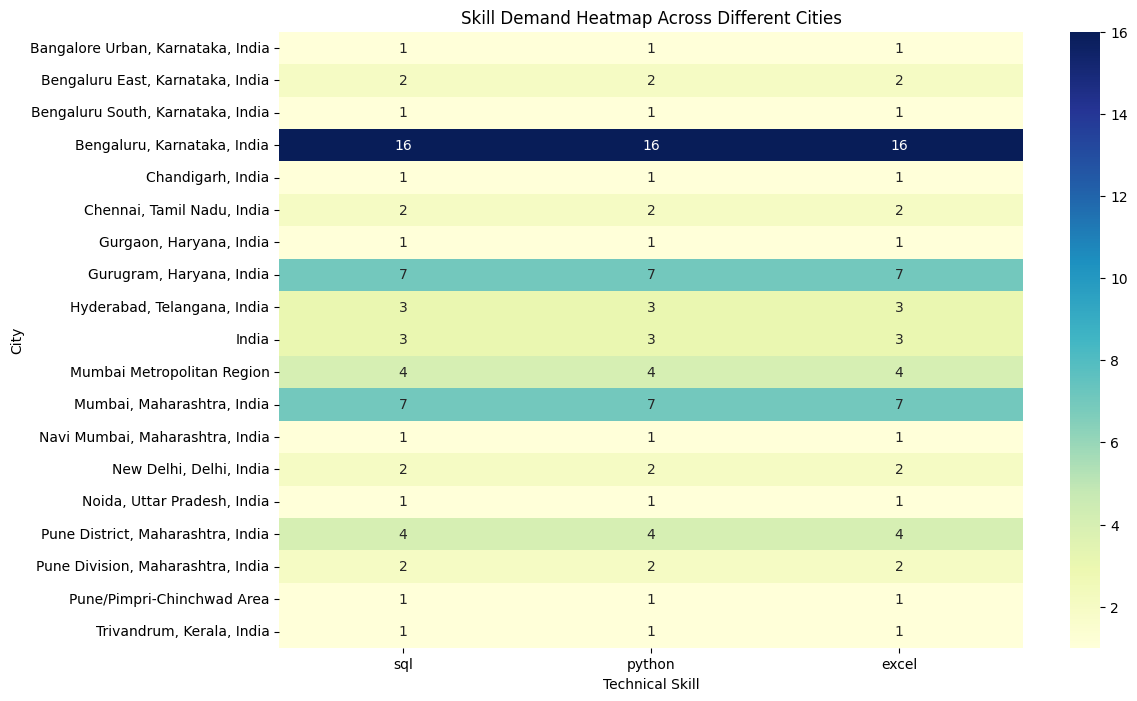

In [13]:
# Top Skills by City (Heatmap) ---
# Create a matrix of Cities vs Skills
city_skill_matrix = exploded_df.groupby(['Location', 'Skill']).size().unstack(fill_value=0)
# Filter for the top 10 most popular skills for a cleaner view
top_10_skills = exploded_df['Skill'].value_counts().head(10).index
city_skill_matrix = city_skill_matrix[top_10_skills]

plt.figure(figsize=(12, 8))
sns.heatmap(city_skill_matrix, annot=True, cmap='YlGnBu', fmt='g')
plt.title('Skill Demand Heatmap Across Different Cities')
plt.xlabel('Technical Skill')
plt.ylabel('City')
plt.savefig('city_skill_heatmap.png')
plt.show()



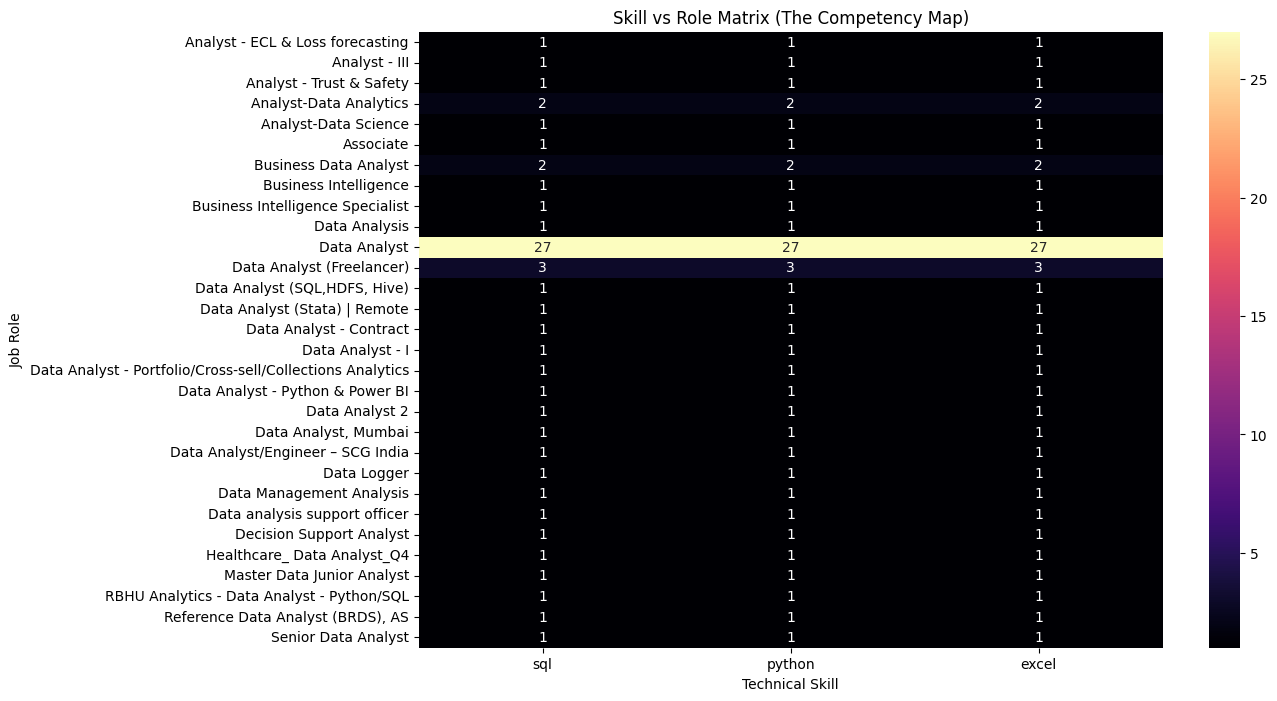

In [15]:
# Skill vs Role Matrix (Job Demand Recommendation) ---
# Create a matrix of Job Titles vs Skills
role_skill_matrix = exploded_df.groupby(['Job Title', 'Skill']).size().unstack(fill_value=0)
role_skill_matrix = role_skill_matrix[top_10_skills]

plt.figure(figsize=(12, 8))
sns.heatmap(role_skill_matrix, annot=True, cmap='magma', fmt='g')
plt.title('Skill vs Role Matrix (The Competency Map)')
plt.xlabel('Technical Skill')
plt.ylabel('Job Role')
plt.savefig('role_skill_matrix.png')
plt.show()

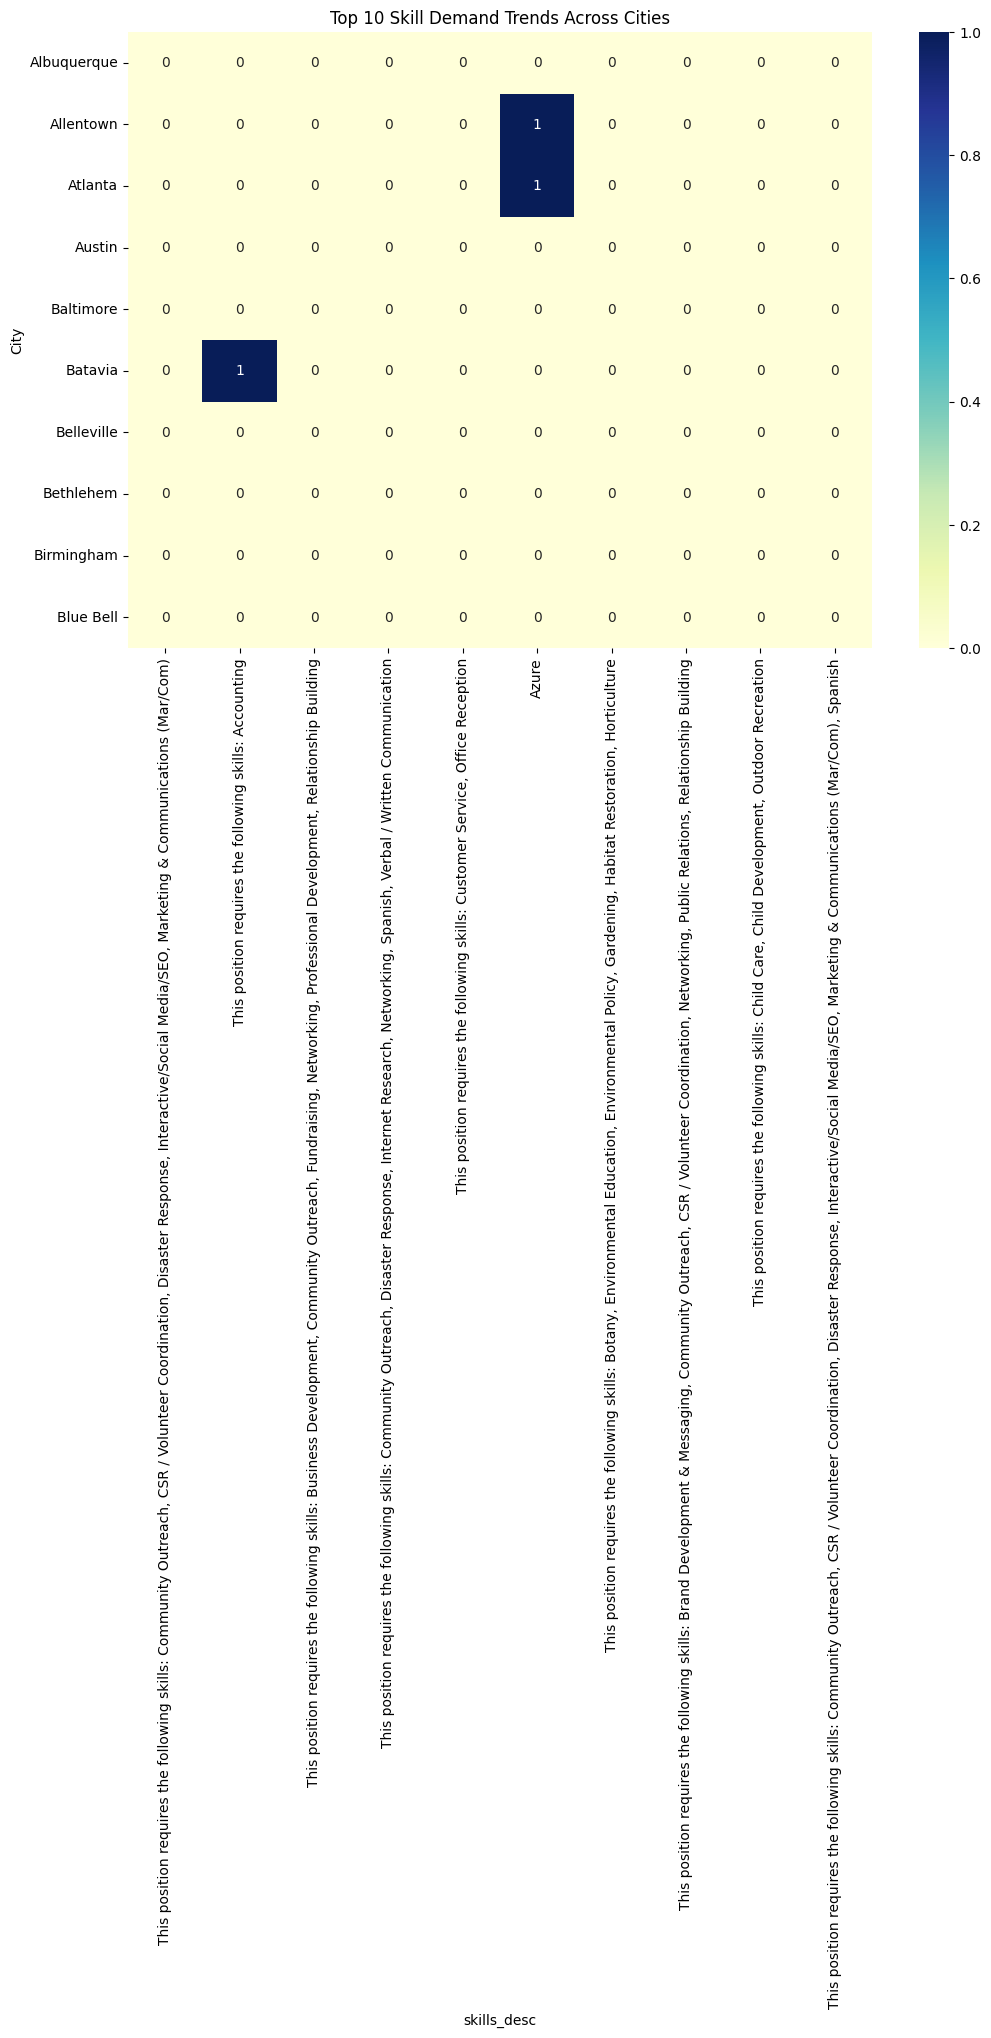

In [7]:
#  Trend Analysis: Top 10 Skills by City (The Heatmap logic)
# We count the frequency of skill tags appearing per city
skill_city_counts = df.groupby(['City', 'skills_desc']).size().unstack(fill_value=0)
top_skills = skill_city_counts.sum().nlargest(10).index
heatmap_data = skill_city_counts[top_skills].head(10)

#  Visualization
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt='g')
plt.title('Top 10 Skill Demand Trends Across Cities')
plt.savefig('skill_city_heatmap.png')
plt.show()

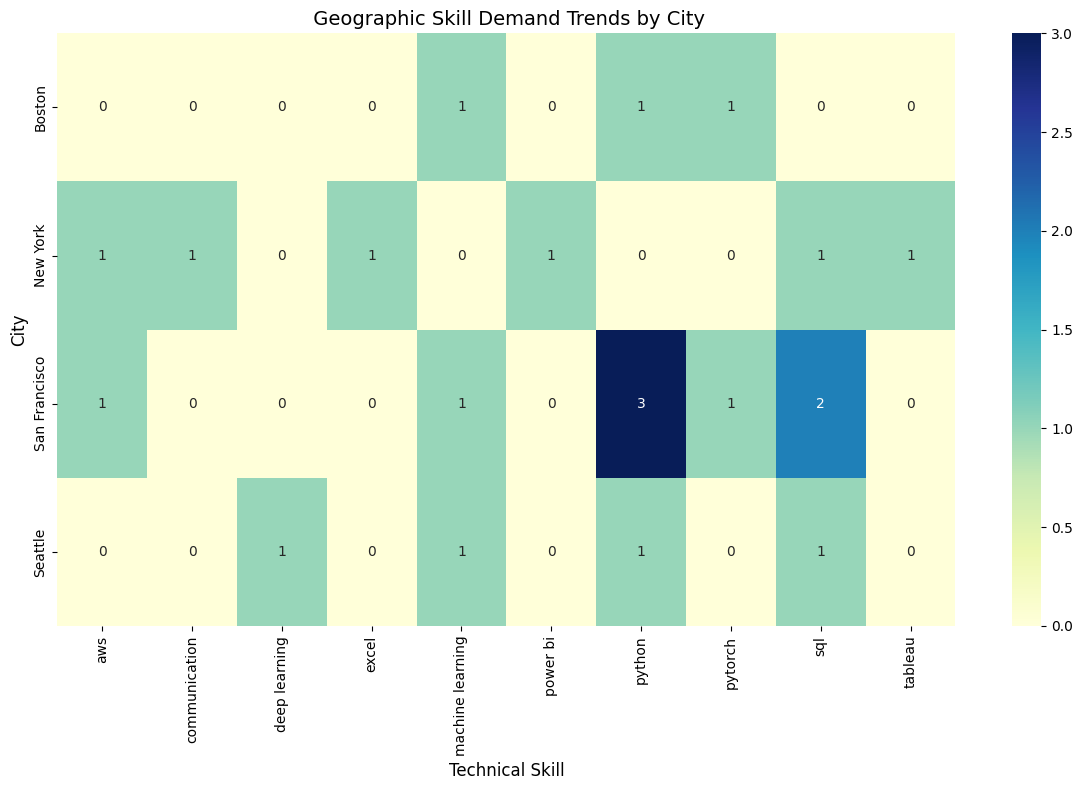

In [38]:
# Geographic Trend (City vs. Skill Heatmap) ---

# Ensure job_df has 'City' column and then create exploded_df from it
# job_df is expected to be available from previous cells (oaC3NZv1c7qb, 3UvVSlcdc-mp)
job_df['City'] = job_df['Location'].str.split(',').str[0]

# Add a sample 'Posted_Date' column to job_df for time-series analysis
# This assumes job_df has 8 rows as per previous sample data setup.
job_df['Posted_Date'] = pd.to_datetime(['2025-01-05', '2025-01-15', '2025-02-10', '2025-02-20',
                                        '2025-03-05', '2025-03-15', '2025-01-20', '2025-03-25'])

# Robust Parsing & Exploding for skills
job_df['Skill_List'] = job_df['Cleaned_Skills'].apply(lambda x: [s.strip() for s in x.split(',')])
exploded_df = job_df.explode('Skill_List')
exploded_df.rename(columns={'Skill_List': 'Skill'}, inplace=True)

# Filter global top 10 skills to keep the heatmap readable
# top_10_skills is expected to be defined from cell 0jOJMpGThXmO
top_10_list = top_10_skills.index.tolist() # Corrected: Get skill names (index), not counts (values)

city_skill_matrix = exploded_df[exploded_df['Skill'].isin(top_10_list)].groupby(['City', 'Skill']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(city_skill_matrix, annot=True, cmap='YlGnBu', fmt='g')
plt.title(' Geographic Skill Demand Trends by City', fontsize=14)
plt.xlabel('Technical Skill', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.tight_layout()
plt.savefig('linkedin_city_skill_heatmap.png')

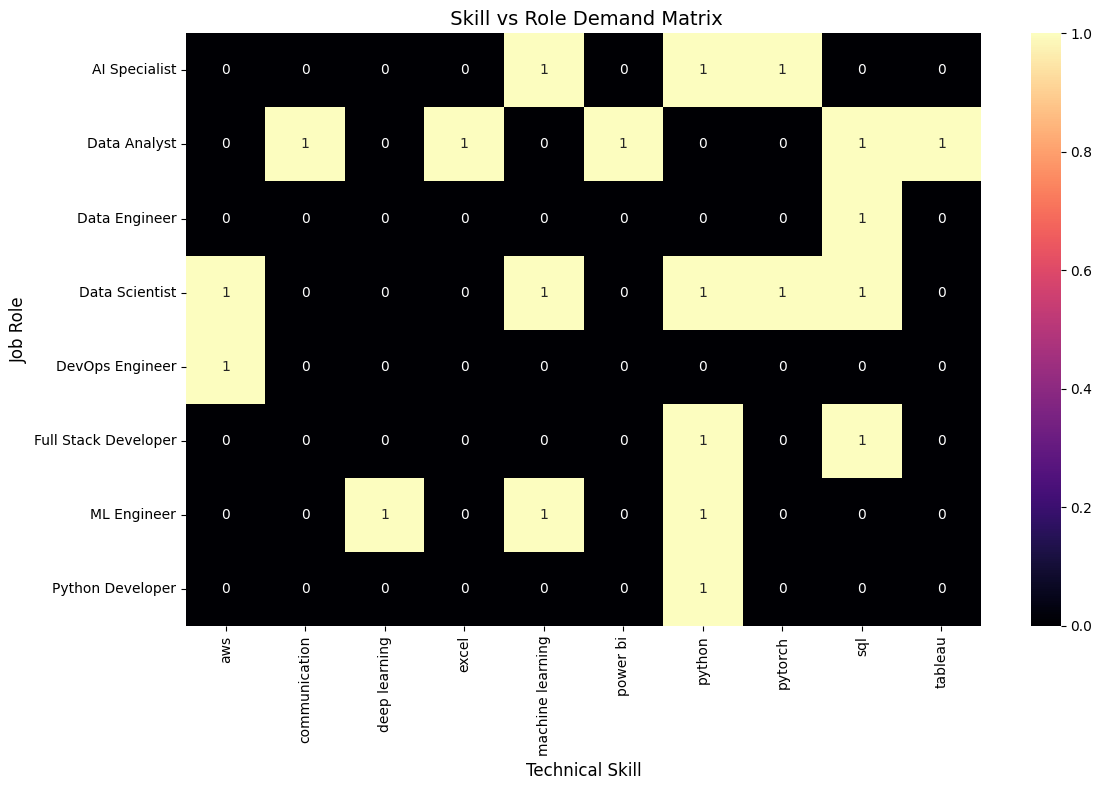

In [20]:
# Skill vs Role Matrix (Competency Map) ---
role_skill_matrix = exploded_df[exploded_df['Skill'].isin(top_skills.index)].groupby(['Job_Title', 'Skill']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(role_skill_matrix, annot=True, cmap='magma', fmt='g')
plt.title(' Skill vs Role Demand Matrix', fontsize=14)
plt.xlabel('Technical Skill', fontsize=12)
plt.ylabel('Job Role', fontsize=12)
plt.tight_layout()
plt.savefig('linkedin_role_skill_matrix.png')

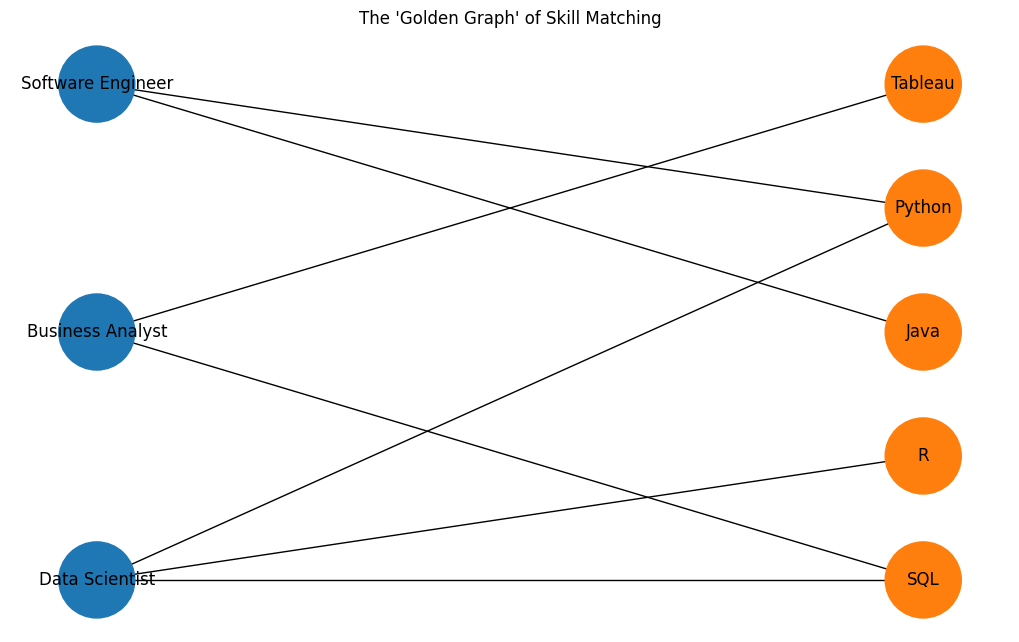

In [8]:
import networkx as nx

# Create a Bipartite Graph
B = nx.Graph()

# Nodes
roles = ['Data Scientist', 'Business Analyst', 'Software Engineer']
skills = ['Python', 'SQL', 'Java', 'Tableau', 'R']

B.add_nodes_from(roles, bipartite=0)
B.add_nodes_from(skills, bipartite=1)

# Edges (Skill Requirements)
B.add_edges_from([
    ('Data Scientist', 'Python'), ('Data Scientist', 'SQL'), ('Data Scientist', 'R'),
    ('Business Analyst', 'SQL'), ('Business Analyst', 'Tableau'),
    ('Software Engineer', 'Python'), ('Software Engineer', 'Java')
])

# Visualize the Matching Logic
plt.figure(figsize=(10, 6))
pos = nx.bipartite_layout(B, roles)
nx.draw(B, pos, with_labels=True, node_color=['#1f77b4']*len(roles) + ['#ff7f0e']*len(skills), node_size=3000)
plt.title("The 'Golden Graph' of Skill Matching")
plt.show()

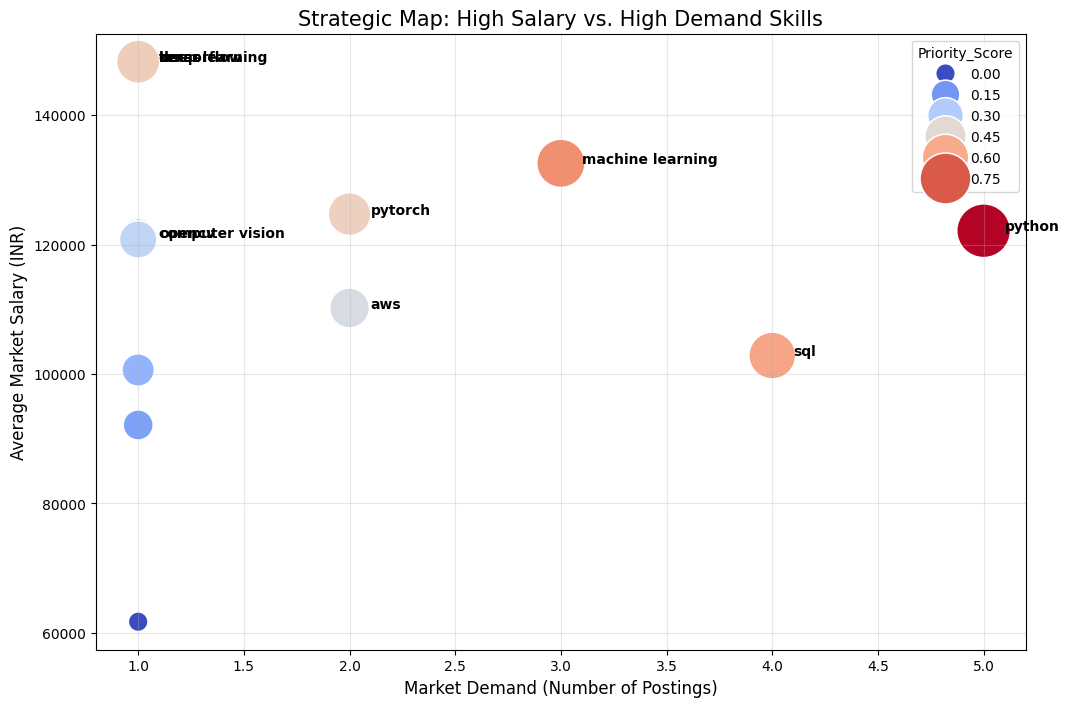

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Map Skills to Salary (Assuming 'exploded_df' from your previous step)
# This calculates the average salary associated with each skill mention
skill_salary = exploded_df.groupby('Skill')['Salary_INR'].mean().sort_values(ascending=False)

#  Analyze "High Demand" Skills (Frequency)
skill_demand = exploded_df['Skill'].value_counts()

#  Create the "ROI Strategy Matrix" (Return on Investment)
roi_df = pd.DataFrame({
    'Average_Salary': skill_salary,
    'Demand_Count': skill_demand
}).fillna(0)

# Normalize for a combined "Priority Score" (0 to 1 scale)
# Priority Score = (Salary + Demand) / 2
roi_df['Salary_Score'] = (roi_df['Average_Salary'] - roi_df['Average_Salary'].min()) / (roi_df['Average_Salary'].max() - roi_df['Average_Salary'].min())
roi_df['Demand_Score'] = (roi_df['Demand_Count'] - roi_df['Demand_Count'].min()) / (roi_df['Demand_Count'].max() - roi_df['Demand_Count'].min())
roi_df['Priority_Score'] = (roi_df['Salary_Score'] + roi_df['Demand_Score']) / 2

# Sort by Priority to find the best skills for your next job
roi_df = roi_df.sort_values(by='Priority_Score', ascending=False)

# Visualization: Salary vs. Demand Bubble Chart
plt.figure(figsize=(12, 8))
# Bubble size represents the 'Priority Score'
sns.scatterplot(data=roi_df, x='Demand_Count', y='Average_Salary',
                size='Priority_Score', sizes=(200, 1500), hue='Priority_Score', palette='coolwarm')

# Annotate the Top 10 High-ROI Skills
for i in range(10):
    plt.text(roi_df['Demand_Count'].iloc[i]+0.1, roi_df['Average_Salary'].iloc[i],
             roi_df.index[i], weight='bold', fontsize=10)

plt.title('Strategic Map: High Salary vs. High Demand Skills', fontsize=15)
plt.xlabel('Market Demand (Number of Postings)', fontsize=12)
plt.ylabel('Average Market Salary (INR)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig('salary_vs_demand_roi.png')
plt.show()

/tmp/ipykernel_15064/2276529211.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(prediction_df.Current_Volume[i]+0.1, prediction_df.Growth_Velocity_Pct[i],


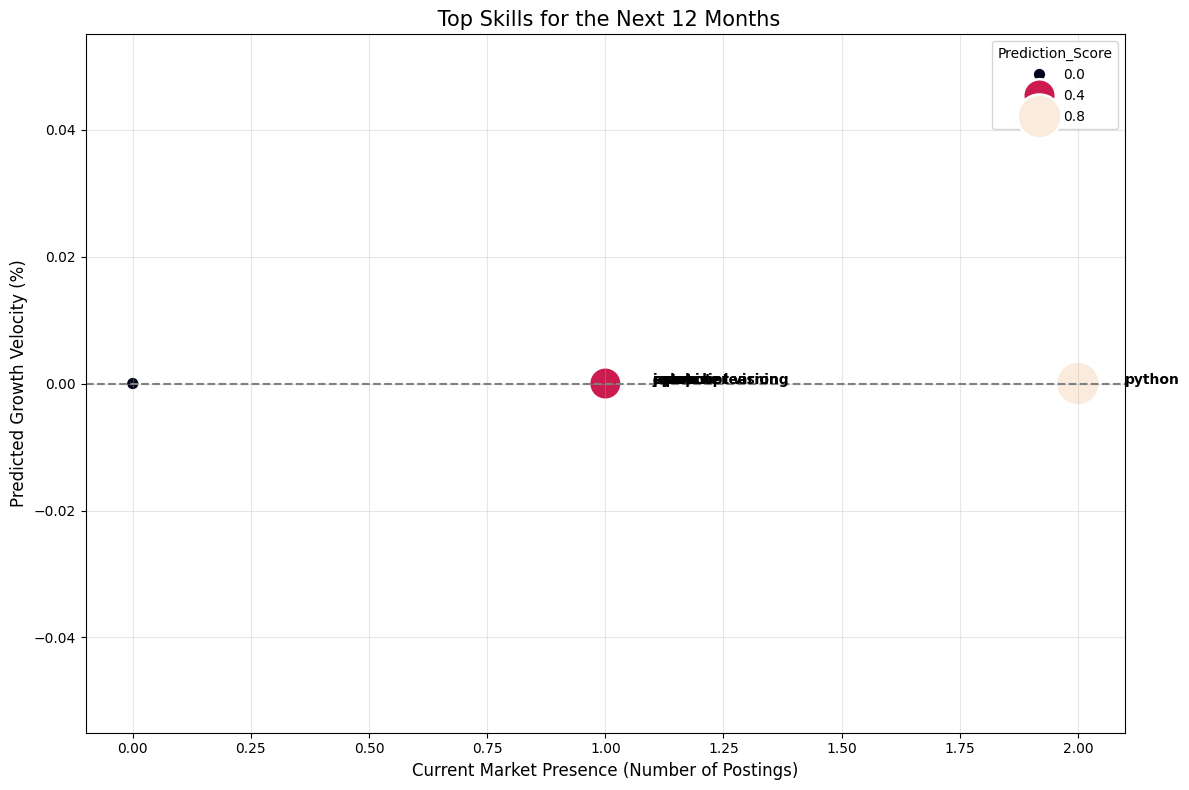

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Prepare Time-Series Data (Assuming 'exploded_df' from your previous step)
# Ensure we have a Month column to track growth
exploded_df['Month'] = pd.to_datetime(exploded_df['Posted_Date']).dt.to_period('M')
skill_trend = exploded_df.groupby(['Month', 'Skill']).size().unstack(fill_value=0)

#  Calculate Growth Velocity (Predictive Logic)
# Percentage change between the most recent months
velocity = skill_trend.pct_change().iloc[-1] * 100
velocity = velocity.replace([np.inf, -np.inf], np.nan).fillna(0)

#  Predict Top 10 Skills for Next Year
# We weigh both Current Volume (Market Share) and Velocity (Growth)
current_volume = skill_trend.iloc[-1]
prediction_score = (current_volume * 0.4) + (velocity * 0.6) # Weighted score

prediction_df = pd.DataFrame({
    'Current_Volume': current_volume,
    'Growth_Velocity_Pct': velocity,
    'Prediction_Score': prediction_score
}).sort_values(by='Prediction_Score', ascending=False)

# 4. Visualization: The Future Skill Opportunity Matrix
plt.figure(figsize=(12, 8))
# Use a Scatter Plot to show Volume vs. Growth
sns.scatterplot(data=prediction_df.head(15), x='Current_Volume', y='Growth_Velocity_Pct',
                size='Prediction_Score', sizes=(100, 1000), hue='Prediction_Score', palette='rocket')

# Annotate the Top 10 predicted skills
for i in range(10):
    plt.text(prediction_df.Current_Volume[i]+0.1, prediction_df.Growth_Velocity_Pct[i],
             prediction_df.index[i], weight='bold', fontsize=10)

plt.axhline(0, color='gray', linestyle='--')
plt.title(' Top Skills for the Next 12 Months', fontsize=15)
plt.xlabel('Current Market Presence (Number of Postings)', fontsize=12)
plt.ylabel('Predicted Growth Velocity (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('next_year_top_skills.png')
plt.show()

In [43]:
#  Extract the Top 10 predicted skills based on the weighted score
top_10_future_skills = prediction_df.head(10)

#  Display the results for the project report
print("--- NEXT YEAR'S TOP 10 SKILLS (PREDICTIVE ANALYSIS) ---")
print(top_10_future_skills[['Current_Volume', 'Growth_Velocity_Pct', 'Prediction_Score']])

# Quick Visual Check: Ensure the labels match the data
for rank, (skill, row) in enumerate(top_10_future_skills.iterrows(), 1):
    print(f"Rank {rank}: {skill} (Score: {row['Prediction_Score']:.2f})")

--- NEXT YEAR'S TOP 10 SKILLS (PREDICTIVE ANALYSIS) ---
                  Current_Volume  Growth_Velocity_Pct  Prediction_Score
Skill                                                                  
python                         2                  0.0               0.8
azure                          1                  0.0               0.4
computer vision                1                  0.0               0.4
javascript                     1                  0.0               0.4
aws                            1                  0.0               0.4
react                          1                  0.0               0.4
sql                            1                  0.0               0.4
pytorch                        1                  0.0               0.4
opencv                         1                  0.0               0.4
machine learning               1                  0.0               0.4
Rank 1: python (Score: 0.80)
Rank 2: azure (Score: 0.40)
Rank 3: computer vision